## INFS-768 Deliverable 2

Collin Brueggeman

## Problem Statement

Stroke is one of the leading causes of death and disability worldwide. Early prediction of stroke risk can lead to preventive healthcare interventions and reduce healthcare costs. Existing research shows that machine learning models can effectively identify high-risk individuals using health and lifestyle indicators.

The objective of this project is to use predictive analytics to develop a model that predicts the likelihood of stroke occurrence based on patient health attributes. This application of predictive analytics has practical significance for healthcare providers seeking to provide preventive care resources more effectively and can also help individuals make better health decisions.

My problem statement is supported by this systematic review F. Asadi, M. Rahimi, A. H. Daeechini, and A. Paghe, “The most efficient machine learning algorithms in stroke prediction: A systematic review,” Health Science Reports, vol. 7, no. 10, Oct. 2024, doi: https://doi.org/10.1002/hsr2.70062. as it highligts stroke being a major issue and that machine learning/predictive analytics is a growing method of early risk predictions. 

The objective of my project is supported by E. Alanazi, A. Abdou, and J. Luo, “Predicting risk of stroke from lab tests using machine learning algorithms (Preprint),” JMIR Formative Research, Aug. 2020, doi: https://doi.org/10.2196/23440. which details models built on health atributes to predict stroke risk which validates my approach.

## Exploratory Data Analysis

In [ ]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn import preprocessing

# Import data into pandas dataframe
heart_data = pd.read_csv('healthcare-dataset-stroke-data.csv')

In [46]:
# Basic information about the dataset
print("Dataset Shape:", heart_data.shape)
print("\nData Types:")
print(heart_data.dtypes)
print("\nMissing Values:")
print(heart_data.isnull().sum())
print("\nDataset Info:")
heart_data.info()

Dataset Shape: (5110, 12)

Data Types:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Missing Values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1 

In [47]:
# Descriptive statistics for numeric variables
heart_data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


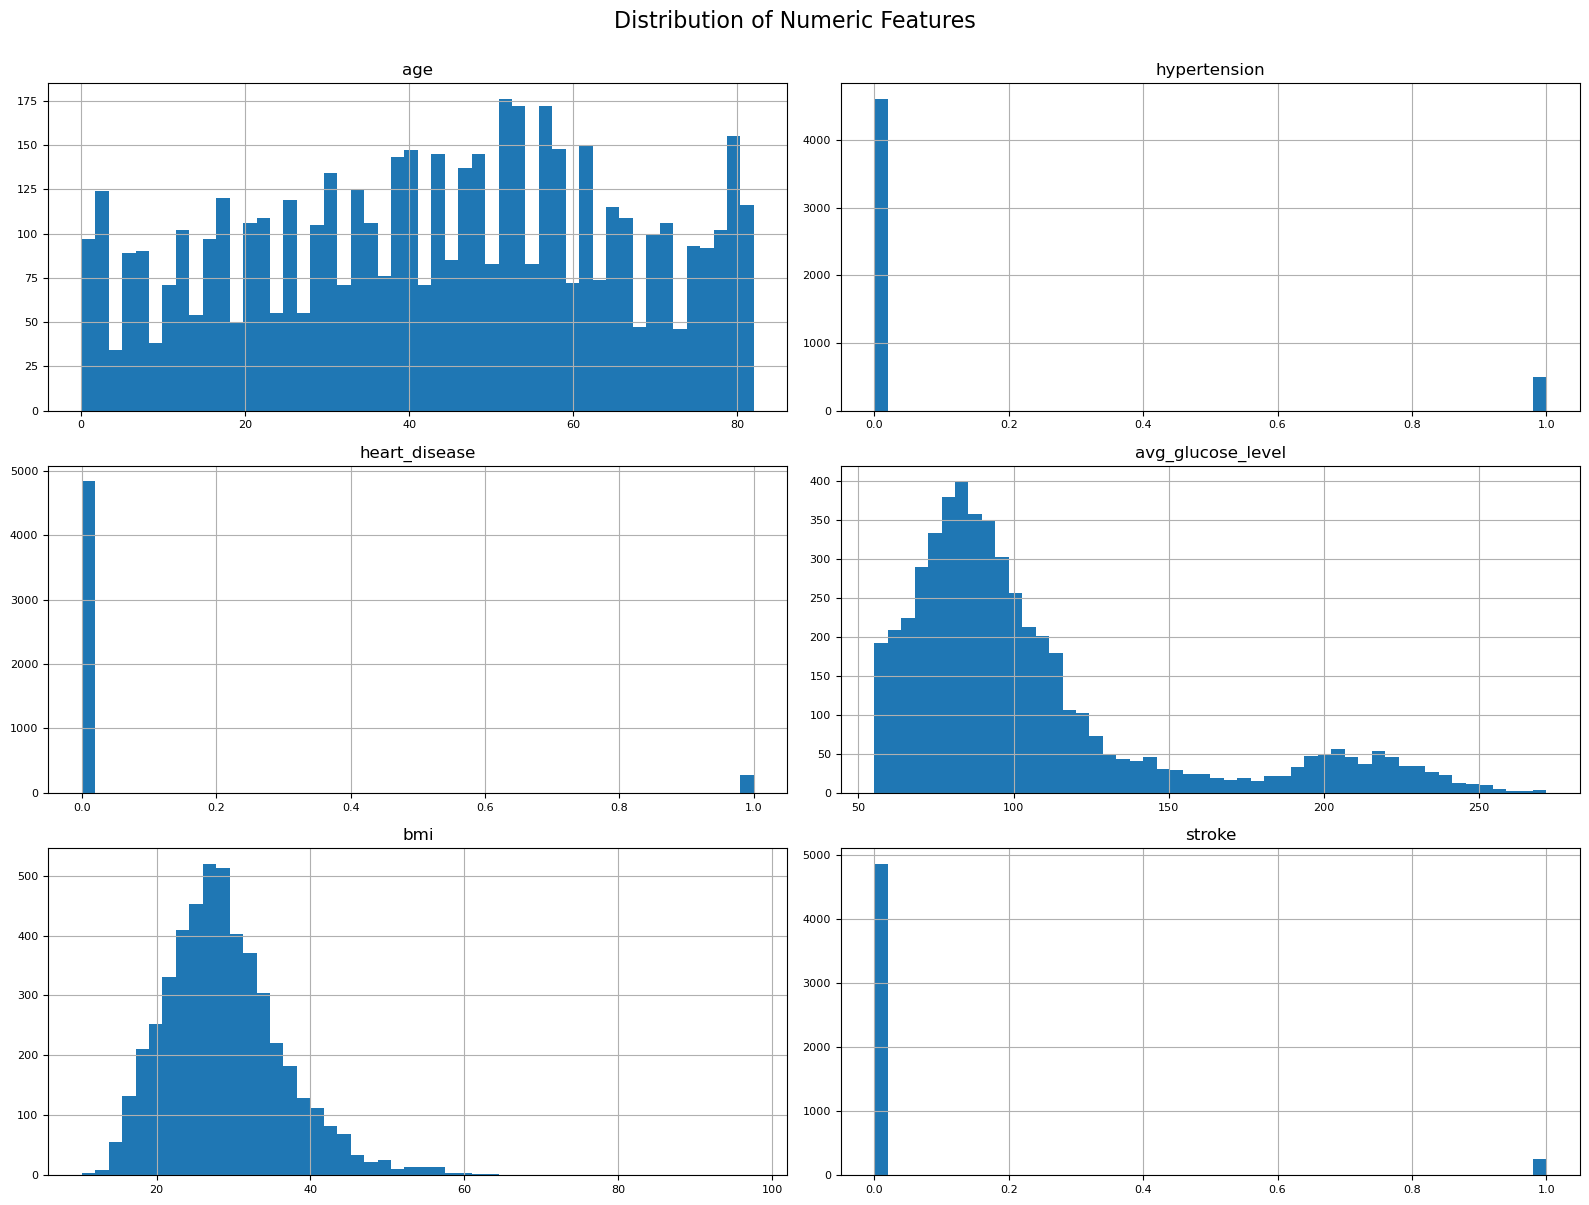

In [48]:
# Select numeric features for visualization
heart_data_num = heart_data.select_dtypes(include=['float64', 'int64'])

# Drop ID feature as it's not meaningful for analysis
heart_data_num = heart_data_num.drop('id', axis=1)

# Create histograms of numeric features
heart_data_num.hist(figsize=(16, 12), bins=50, xlabelsize=8, ylabelsize=8)
plt.suptitle('Distribution of Numeric Features', fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

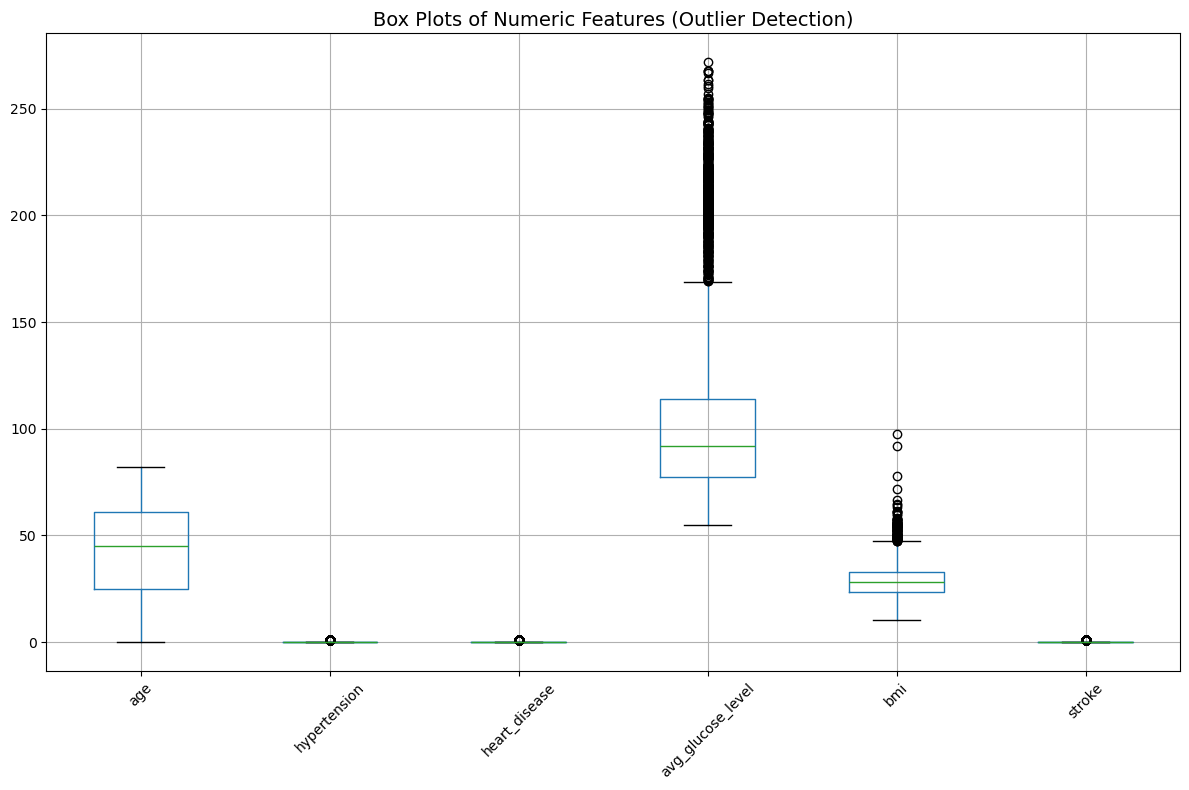

In [49]:
# Box plots for numeric features to identify outliers
plt.figure(figsize=(12, 8))
heart_data_num.boxplot()
plt.title('Box Plots of Numeric Features (Outlier Detection)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

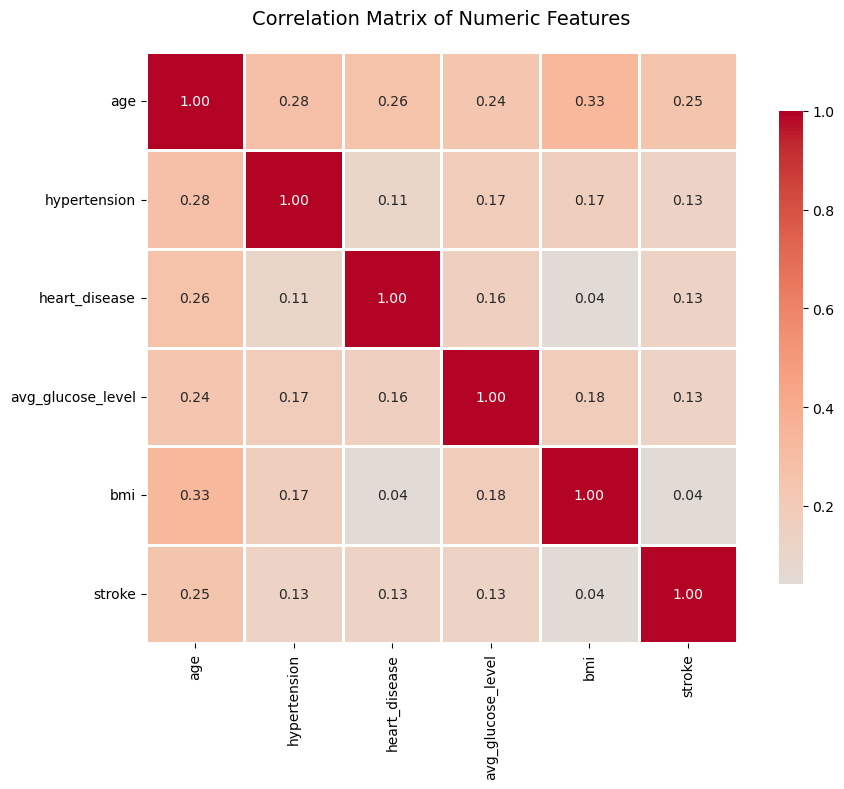

In [50]:
# Correlation matrix heatmap
correlation_matrix = heart_data_num.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numeric Features', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

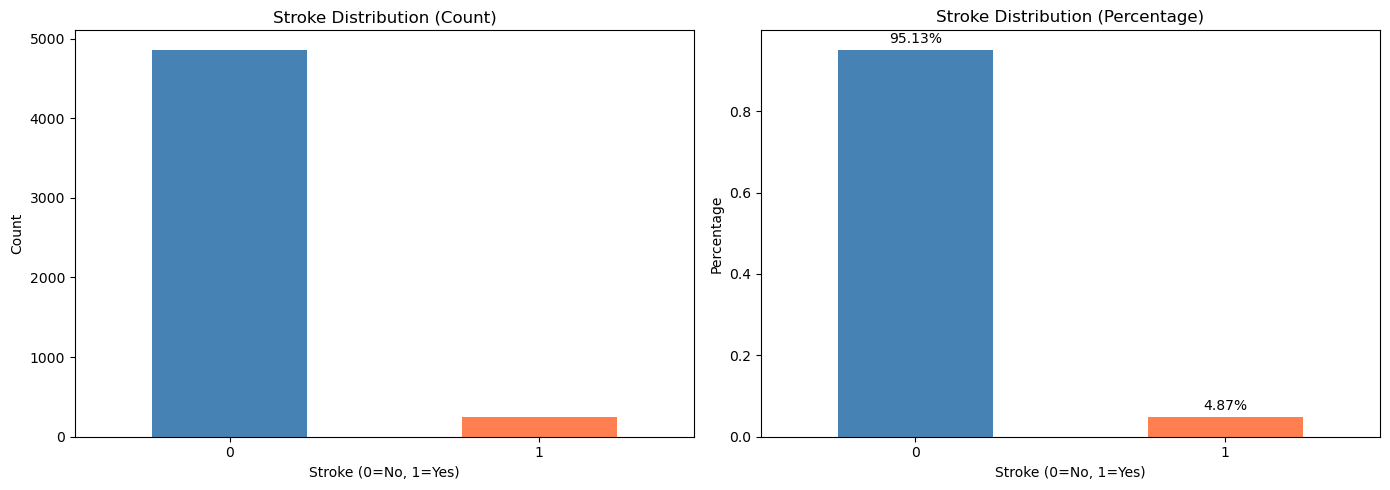

Stroke Distribution:
stroke
0    4861
1     249
Name: count, dtype: int64

Stroke Percentage:
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [51]:
# Visualize class imbalance in target variable (stroke)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
heart_data['stroke'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Stroke Distribution (Count)', fontsize=12)
axes[0].set_xlabel('Stroke (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Percentage plot
heart_data['stroke'].value_counts(normalize=True).plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_title('Stroke Distribution (Percentage)', fontsize=12)
axes[1].set_xlabel('Stroke (0=No, 1=Yes)')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=0)

# Add percentage labels
for i, (idx, val) in enumerate(heart_data['stroke'].value_counts(normalize=True).items()):
    axes[1].text(i, val + 0.01, f'{val*100:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print exact counts
print("Stroke Distribution:")
print(heart_data['stroke'].value_counts())
print("\nStroke Percentage:")
print(heart_data['stroke'].value_counts(normalize=True) * 100)


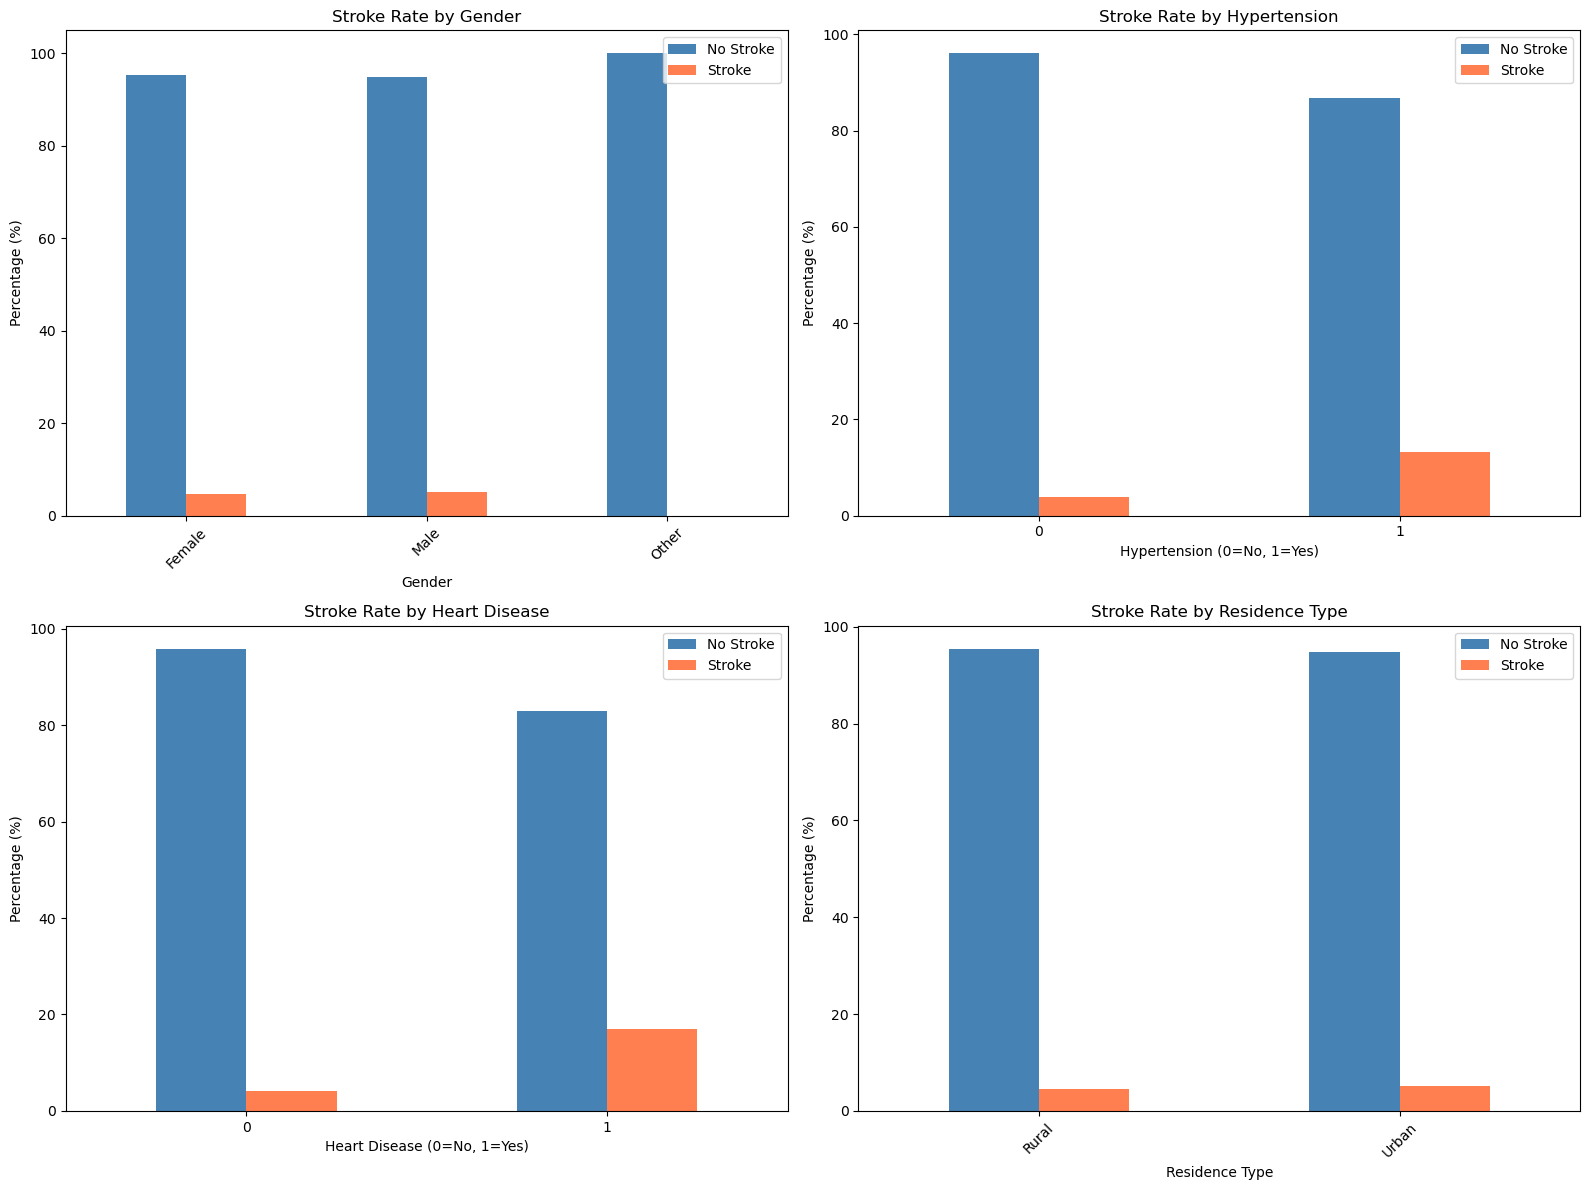

In [52]:
# Analyze stroke rates by categorical variables
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Stroke by gender
gender_stroke = pd.crosstab(heart_data['gender'], heart_data['stroke'], normalize='index') * 100
gender_stroke.plot(kind='bar', ax=axes[0, 0], color=['steelblue', 'coral'])
axes[0, 0].set_title('Stroke Rate by Gender', fontsize=12)
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Percentage (%)')
axes[0, 0].legend(['No Stroke', 'Stroke'])
axes[0, 0].tick_params(axis='x', rotation=45)

# Stroke by hypertension
hypertension_stroke = pd.crosstab(heart_data['hypertension'], heart_data['stroke'], normalize='index') * 100
hypertension_stroke.plot(kind='bar', ax=axes[0, 1], color=['steelblue', 'coral'])
axes[0, 1].set_title('Stroke Rate by Hypertension', fontsize=12)
axes[0, 1].set_xlabel('Hypertension (0=No, 1=Yes)')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].legend(['No Stroke', 'Stroke'])
axes[0, 1].tick_params(axis='x', rotation=0)

# Stroke by heart disease
heart_stroke = pd.crosstab(heart_data['heart_disease'], heart_data['stroke'], normalize='index') * 100
heart_stroke.plot(kind='bar', ax=axes[1, 0], color=['steelblue', 'coral'])
axes[1, 0].set_title('Stroke Rate by Heart Disease', fontsize=12)
axes[1, 0].set_xlabel('Heart Disease (0=No, 1=Yes)')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].legend(['No Stroke', 'Stroke'])
axes[1, 0].tick_params(axis='x', rotation=0)

# Stroke by residence type
residence_stroke = pd.crosstab(heart_data['Residence_type'], heart_data['stroke'], normalize='index') * 100
residence_stroke.plot(kind='bar', ax=axes[1, 1], color=['steelblue', 'coral'])
axes[1, 1].set_title('Stroke Rate by Residence Type', fontsize=12)
axes[1, 1].set_xlabel('Residence Type')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].legend(['No Stroke', 'Stroke'])
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

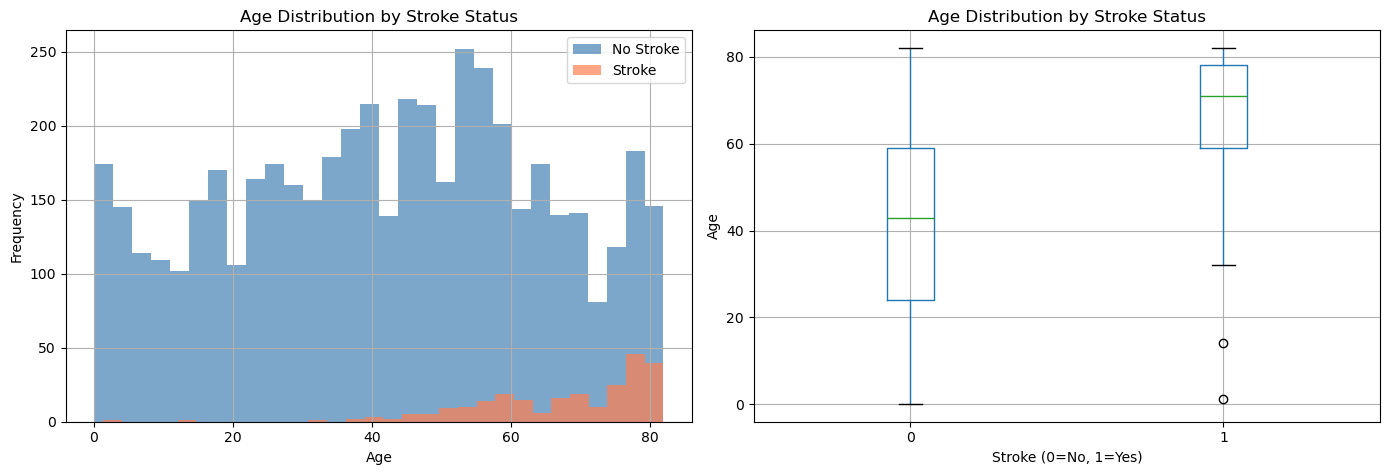

Age Statistics by Stroke Status:
         count       mean        std   min   25%   50%   75%   max
stroke                                                            
0       4861.0  41.971545  22.291940  0.08  24.0  43.0  59.0  82.0
1        249.0  67.728193  12.727419  1.32  59.0  71.0  78.0  82.0


In [53]:
# Age distribution by stroke status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
heart_data[heart_data['stroke'] == 0]['age'].hist(ax=axes[0], bins=30, alpha=0.7, label='No Stroke', color='steelblue')
heart_data[heart_data['stroke'] == 1]['age'].hist(ax=axes[0], bins=30, alpha=0.7, label='Stroke', color='coral')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Age Distribution by Stroke Status')
axes[0].legend()

# Box plot
heart_data.boxplot(column='age', by='stroke', ax=axes[1])
axes[1].set_xlabel('Stroke (0=No, 1=Yes)')
axes[1].set_ylabel('Age')
axes[1].set_title('Age Distribution by Stroke Status')
axes[1].get_figure().suptitle('')  

plt.tight_layout()
plt.show()

# Print age statistics by stroke
print("Age Statistics by Stroke Status:")
print(heart_data.groupby('stroke')['age'].describe())

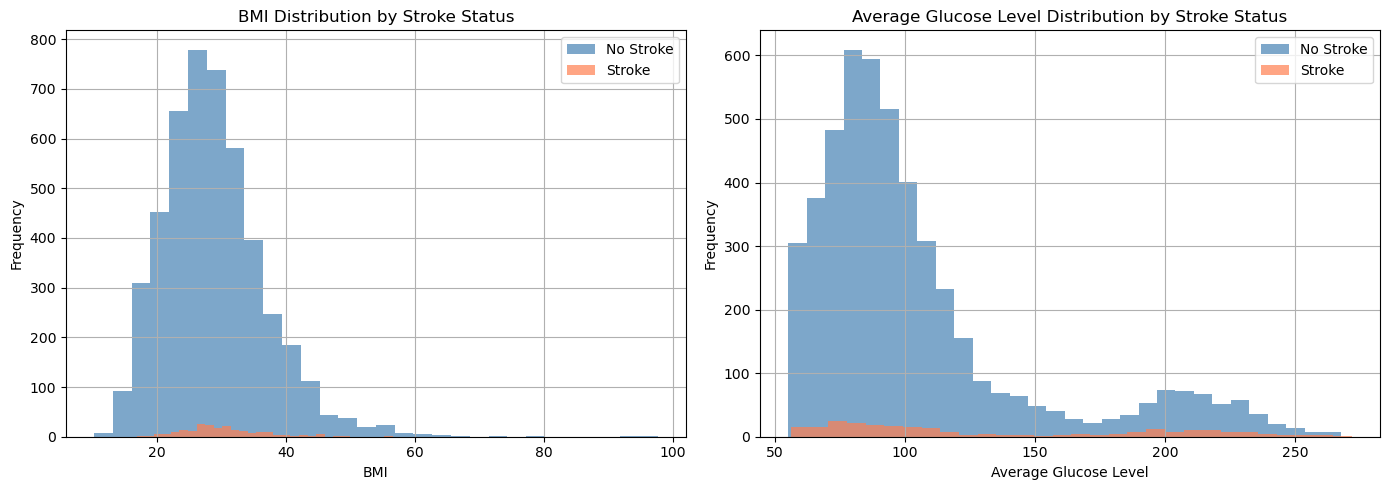

BMI Statistics by Stroke Status:
         count       mean       std   min   25%   50%   75%   max
stroke                                                           
0       4700.0  28.823064  7.908287  10.3  23.4  28.0  33.1  97.6
1        209.0  30.471292  6.329452  16.9  26.4  29.7  33.7  56.6

Average Glucose Level Statistics by Stroke Status:
         count        mean        std    min    25%     50%     75%     max
stroke                                                                     
0       4861.0  104.795513  43.846069  55.12  77.12   91.47  112.83  267.76
1        249.0  132.544739  61.921056  56.11  79.79  105.22  196.71  271.74


In [54]:
# BMI and glucose level distributions by stroke status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BMI
heart_data[heart_data['stroke'] == 0]['bmi'].dropna().hist(ax=axes[0], bins=30, alpha=0.7, label='No Stroke', color='steelblue')
heart_data[heart_data['stroke'] == 1]['bmi'].dropna().hist(ax=axes[0], bins=30, alpha=0.7, label='Stroke', color='coral')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Frequency')
axes[0].set_title('BMI Distribution by Stroke Status')
axes[0].legend()

# Average glucose level
heart_data[heart_data['stroke'] == 0]['avg_glucose_level'].hist(ax=axes[1], bins=30, alpha=0.7, label='No Stroke', color='steelblue')
heart_data[heart_data['stroke'] == 1]['avg_glucose_level'].hist(ax=axes[1], bins=30, alpha=0.7, label='Stroke', color='coral')
axes[1].set_xlabel('Average Glucose Level')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Average Glucose Level Distribution by Stroke Status')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print statistics
print("BMI Statistics by Stroke Status:")
print(heart_data.groupby('stroke')['bmi'].describe())
print("\nAverage Glucose Level Statistics by Stroke Status:")
print(heart_data.groupby('stroke')['avg_glucose_level'].describe())


### Interpretation of Exploratory Data Analysis Results and Why it Matters

The exploratory data analysis reveals several critical patterns, anomalies, and potential biases that have significant implications for predictive modeling and clinical decision-making. 

**Patterns and Relationships:**

The most striking finding is the severe class imbalance in the target variable, with only 4.87% of the dataset representing stroke cases (249 out of 5,110 patients). This extreme imbalance poses a challenge for predictive modeling, as algorithms may default to predicting the majority class, leading to high accuracy but poor recall for stroke cases which is the exact outcome we want to identify. The correlation analysis reveals that age shows the strongest positive correlation with stroke (approximately 0.25), followed by hypertension and heart disease, which aligns with established medical knowledge that stroke risk increases with age and the presence of cardiovascular comorbidities. Notably, the box plots and histograms reveal potential outliers in BMI and average glucose level, with some values extending well beyond typical clinical ranges (e.g., BMI values above 60 and glucose levels exceeding 200 mg/dL). While these may represent genuine extreme cases, they warrant careful investigation to determine if they indicate data quality issues or represent rare but valid clinical presentations that should be preserved in the model.

**Anomalies and Data Quality Concerns:**

The dataset contains 201 missing values in the BMI feature (approximately 3.9% of observations), which introduces uncertainty in model development and requires imputation strategies. The distribution analysis shows that average glucose levels are right-skewed, with a mean significantly higher than the median, suggesting the presence of hyperglycemic outliers that may disproportionately influence model performance. Additionally, gender distribution shows approximately 59% female representation, which could introduce demographic bias if not properly addressed during model validation. The smoking_status has a substantial "Unknown" category (approximately 30.7%), both of which complicate feature engineering and may mask important predictive relationships.

**Why This Matters:**

These findings matter critically because stroke prediction models deployed in healthcare settings have life-or-death consequences where a false negative (missed stroke prediction) could delay critical interventions, while false positives could lead to unnecessary medical procedures and patient anxiety. The class imbalance means that traditional accuracy metrics will be misleading. The focus will need to be on recall, precision, and F1-score to ensure the model can reliably identify at-risk individuals. The strong age-stroke correlation suggests that age should be a cornerstone feature, but the moderate correlations with hypertension and heart disease indicate that stroke prediction requires considering multiple interacting risk factors rather than relying on single predictors. The missing BMI data and outliers in glucose/BMI require validation to ensure the preprocessing decisions align with clinical realities. Blindly imputing or removing outliers could either introduce bias or eliminate rare but clinically important cases. Most importantly, the demographic imbalances raise ethical concerns about model fairness. A model that performs well overall but systematically underperforms for certain demographic groups could exacerbate healthcare disparities rather than mitigate them.


## Correlation Analysis

In [55]:
# bivariate analysis
heart_data.drop('id', axis=1).corr(numeric_only=True).round(2)


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
age,1.00,0.28,0.26,0.24,0.33,0.25
hypertension,0.28,1.00,0.11,0.17,0.17,0.13
heart_disease,0.26,0.11,1.00,0.16,0.04,0.13
avg_glucose_level,0.24,0.17,0.16,1.00,0.18,0.13
bmi,0.33,0.17,0.04,0.18,1.00,0.04
stroke,0.25,0.13,0.13,0.13,0.04,1.00


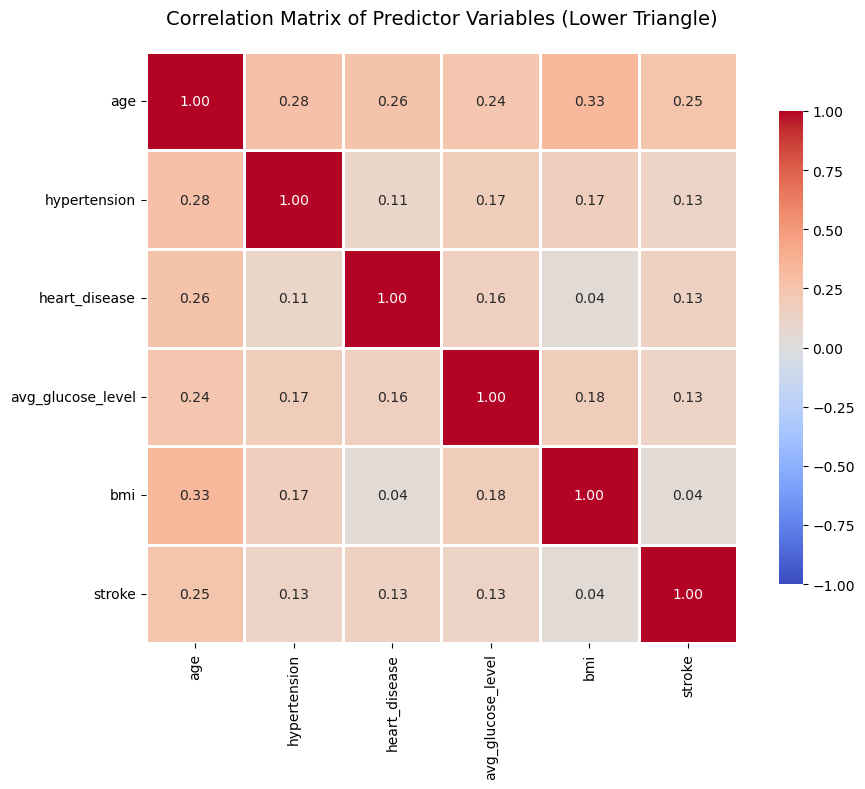

In [56]:
# Enhanced correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
             vmin=-1, vmax=1)
plt.title('Correlation Matrix of Predictor Variables (Lower Triangle)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


### Interpretation of Correlation Analysis and Multicollinearity Assessment

The correlation analysis reveals important relationships between predictor variables and identifies potential multicollinearity concerns that must be addressed before modeling.

**Correlation Patterns:**

The correlation matrix shows relatively low to moderate correlations among predictor variables, which is generally favorable for regression modeling. The strongest correlations observed are between age and hypertension (r ≈ 0.28), age and BMI (r ≈ 0.33), and age and average glucose level (r ≈ 0.24). These relationships align with medical knowledge. Age is a well-established risk factor for developing hypertension, and BMI and glucose levels often increase with age. However, none of these correlations exceed the commonly accepted threshold of 0.7 for multicollinearity concerns, suggesting that including all these variables in a model may be feasible.

Citation:
- Age and hypertension: https://pmc.ncbi.nlm.nih.gov/articles/PMC9521719
- BMI and Glucose: https://pmc.ncbi.nlm.nih.gov/articles/PMC12287539

## Principal Component Analysis

In [81]:
# Perform PCA on numeric features minus ID and stroke
pcs = PCA()
pcs.fit(heart_data.drop(['stroke'], axis=1))

PCA()

In [82]:
pcsSummary_df = pd.DataFrame({'Standard Deviation': np.sqrt(pcs.explained_variance_), 'Proportion of Variance': pcs.explained_variance_ratio_,
                           'Cumulative Proportion': np.cumsum(pcs.explained_variance_ratio_)})

In [83]:

pcsSummary_df  = pcsSummary_df.transpose()
pcsSummary_df.columns = ['PC{}'.format(i) for i in range(1, len(pcsSummary_df.columns) + 1)]
pcsSummary_df.round(4)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
Standard Deviation,45.7221,21.8862,6.9326,0.5623,0.5295,0.5002,0.4786,0.4006,0.3469,0.2916,0.2817,0.2224,0.2139,0.1661,0.0634
Proportion of Variance,0.7981,0.1829,0.0183,0.0001,0.0001,0.0001,0.0001,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Cumulative Proportion,0.7981,0.9810,0.9994,0.9995,0.9996,0.9997,0.9998,0.9998,0.9999,0.9999,1.0000,1.0000,1.0000,1.0000,1.0000


In [84]:
pcsComponents_df = pd.DataFrame(
    pcs.components_.T,
    columns=[f'PC{i}' for i in range(1, pcs.n_components_ + 1)],
    index=heart_data.drop(['stroke'], axis=1).columns
)

pcsComponents_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
gender,-0.000551,0.001053,0.001825,0.238459,0.373193,0.246607,0.857023,-0.040816,-0.039549,-0.054840,0.017550,-0.000360,0.043686,0.009685,0.002913
age,0.153709,0.981359,-0.113964,-0.001886,-0.000239,-0.000661,-0.000832,0.000134,-0.015286,-0.005521,-0.005311,0.000251,-0.003742,0.002855,0.000412
hypertension,0.001249,0.003112,0.001898,-0.025118,0.030445,-0.016046,-0.029827,0.019035,-0.097340,-0.118005,0.980206,-0.078758,-0.045348,-0.066707,-0.002279
heart_disease,0.000883,0.002238,-0.002334,-0.028606,-0.025784,-0.012437,-0.031735,0.013474,-0.086414,-0.017352,0.029941,0.027496,0.989902,-0.088412,-0.004430
ever_married,0.002132,0.014146,0.006970,0.072847,-0.048322,0.007182,0.021863,0.091042,0.939190,-0.288519,0.062020,-0.071751,0.081590,0.045884,0.014426
Residence_type,-0.000041,0.000367,-0.000181,-0.106704,-0.075665,0.966453,-0.217264,-0.038191,0.004660,0.000983,0.009645,-0.008164,0.001129,0.001589,-0.003019
avg_glucose_level,0.987571,-0.156437,-0.015161,0.000621,0.000174,0.000324,0.000607,0.000052,0.000397,0.000459,-0.000643,-0.000047,-0.000471,-0.000187,-0.000025
bmi,0.032680,0.109961,0.993166,-0.015516,0.005099,-0.001301,-0.000752,-0.001135,-0.009859,-0.007300,-0.004536,-0.001426,0.001267,0.003967,0.000353
work_type_Never_worked,-0.000029,-0.000228,-0.000001,-0.001907,0.006908,0.002640,-0.005088,-0.000955,-0.005342,0.008738,-0.001882,0.022993,-0.004319,-0.088316,0.995720
work_type_Private,0.000283,0.002727,0.012591,0.702310,-0.474521,0.034057,0.002122,-0.078818,-0.051198,0.226099,0.056945,-0.314738,0.046410,0.338032,0.039783


### Interpreting Prinicpal Components

From the component loadings:

- PC1 has very high loading on avg_glucose_level (0.9876), this feature dominates PC1, meaning it explains most of the dataset’s variance.
- PC2 is dominated by age (0.9814), this indicates that age represents the second major axis of variability, orthogonal to glucose level.
- PC3 is driven by bmi (0.9932), it explains residual variance related to body mass.

So:

- PC1: Glucose-related variation
- PC2: Age-related variation
- PC3: BMI-related variation

Together, these three components summarize almost all variation in the dataset.

## Data Cleaning

In [ ]:
# Outliers (caps the bmi to the 99th percentile)
upper_cap = heart_data['bmi'].quantile(0.99)
heart_data.loc[heart_data['bmi'] > upper_cap, 'bmi'] = upper_cap

# Missing value imputation (BMI)
median_bmi = heart_data['bmi'].median()
heart_data['bmi'] = heart_data['bmi'].fillna(median_bmi)

# Categorical Handling

# Binary encodings
# Clean and handle the 'Other' category
heart_data['gender'] = heart_data['gender'].replace('Other', np.nan)
heart_data['gender'] = heart_data['gender'].fillna(heart_data['gender'].mode()[0])  # fills with 'Female' (most common)
heart_data['gender'] = heart_data['gender'].map({'Male': 0, 'Female': 1}) # 0 = male and 1 = female

heart_data['ever_married'] = heart_data['ever_married'].map({'No': 0, 'Yes': 1}) # 0 = never married and 1 = married

heart_data['Residence_type'] = heart_data['Residence_type'].map({'Rural': 0, 'Urban': 1}) # 0 = rural and 1 = urban

# One-hot encode multi-class categorical columns
heart_data = pd.get_dummies(heart_data, columns=['work_type', 'smoking_status'], drop_first=True)

# Drop ID (not predictive)
heart_data = heart_data.drop(columns=['id'])


### Justification of cleaning

The above cleaning and encoding methods were taken from the below linked study that looked at 58 different research papers that tackled the task of predicting strokes from medical data. I chose to use these best practices to ground my work in what has been the standard in this area of predictive modeling. BMI outliers needed to be dealt with as the most extreme measurements of BMI I could find were in the 50-60 range. After researching into the glucose levels I decided to keep the original values to take into the fact that the outliers could have to do with people having diabetic conditions. I decided to binary encode the categorical features that only had 2 unique values and dummy encode the rest as that was common practice I found in my reading.

A. A. Soladoye, N. Aderinto, M. R. Popoola, I. A. Adeyanju, A. Osonuga, and D. B. Olawade, “Machine learning techniques for stroke prediction: A systematic review of algorithms, datasets, and regional gaps,” International Journal of Medical Informatics, vol. 203, p. 106041, Jul. 2025, doi: https://doi.org/10.1016/j.ijmedinf.2025.106041.

In [85]:
heart_data.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,0,67.0,0,1,1,1,228.69,36.6,1,False,True,False,False,True,False,False
1,1,61.0,0,0,1,0,202.21,28.1,1,False,False,True,False,False,True,False
2,0,80.0,0,1,1,0,105.92,32.5,1,False,True,False,False,False,True,False
3,1,49.0,0,0,1,1,171.23,34.4,1,False,True,False,False,False,False,True
4,1,79.0,1,0,1,0,174.12,24.0,1,False,False,True,False,False,True,False


In [64]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          5110 non-null   int64  
 1   age                             5110 non-null   float64
 2   hypertension                    5110 non-null   int64  
 3   heart_disease                   5110 non-null   int64  
 4   ever_married                    5110 non-null   int64  
 5   Residence_type                  5110 non-null   int64  
 6   avg_glucose_level               5110 non-null   float64
 7   bmi                             5110 non-null   float64
 8   stroke                          5110 non-null   int64  
 9   work_type_Never_worked          5110 non-null   bool   
 10  work_type_Private               5110 non-null   bool   
 11  work_type_Self-employed         5110 non-null   bool   
 12  work_type_children              51

## Predictive Modeling Approaches

### Logistic Regression

**Description:**

Logistic regression is a very popular and powerful classifier model. Logistic regression predicts the probability of a binary outcome using one or more predictors. A S-shaped (sigmoid) curve maps predicted probabilites between 0 and 1. The model then uses a decision threshold to convert the probability into 0 or 1.

**Why it is appropriate:**

Logistic regression is appropriate to my project because it will provide a fantastic baseline model. One of its strengths is interpretability. The odds ratios will provide insight as to why the model is predicting what it is which is very important in the healthcare field. This simplicity and accesibility make it a great choice for my problem at hand.

Citation: Prachi Saoji, Lakshmi Madireddy, Dr. Ajeet Saoji, (2025)Logistic Regression in Healthcare: Predictive Modelingfor Enhanced Clinical Decision-Making.Journal of Neonatal Surgery,14(22s), 765-769, https://www.jneonatalsurg.com/index.php/jns/article/view/5603/4651

### SVM

**Description:** 

Support Vector Machine is a supervised machine learning algorithm that can be used for classification.  It attempts to find the best boundary, known as hyperplane, that seperates different classes within the data. SVM attempts to maximize the margin between classes as the larger the margin the better the model performs on unseen data.

**Why it is appropriate:**

SVM is appropriate for my project because it has extensive use within the medical field because of its ability to provide high accuracy metrics. This is critical in a field like healthcare where the decisions models make can either be life or death or save/waste resources depending on performance. SVM also has the opportunity for hyperparameter tuning which will provide a way to tune and tweak the algorithm to a great degree.

Citation: Gayatri Dwi Santika, & Valiant Shabri Rabbani. (2025). Stroke Disease Prediction Using Support Vector Machine Method. Proceeding International Conference Of Innovation Science, Technology, Education, Children And Health, 5(1), 123–128. https://doi.org/10.62951/icistech.v5i1.274

### Decision Tree

**Description:**

A decision tree is a supervised learning algorithm used for both classification and regression tasks. It has a hierarchical tree structure which consists of a root node, branches, internal nodes and leaf nodes. It works like a flowchart help to make decisions step by step.

**Why it is appropriate:**

Previous work highlights that decision tree classifiers have already seen use in the healthcare field. Decision trees also are capable of handling both numeric and categorical features which could provide another avenue of predictive power from using it on the raw categorical features that don't have to be encoded. Decision tree is also seen as overall very interpretabile which is very important to my project as when used in the real world professionals in the healthcare field need to know why a patient is at risk for such a serious condition such as a stroke.

Citation: L. Hu and L. Li, “Using Tree-Based Machine Learning for Health Studies: Literature Review and Case Series,” vol. 19, no. 23, pp. 16080–16080, Dec. 2022, doi: https://doi.org/10.3390/ijerph192316080.